In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Ignore  the warnings 
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [3]:
!pip install vit_keras
!pip install tensorflow_addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 9.5 MB/s eta 0:00:00


In [4]:
# data visualisation and manipulation
import numpy as np, pandas as pd, re, matplotlib.pyplot as plt, seaborn as sns, math, random

from matplotlib import style
from collections import Counter

#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score,precision_score, recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
#preprocess.
from keras.preprocessing.image import ImageDataGenerator

#dl libraraies
import tensorflow as tf
from tensorflow.keras import layers
from keras import backend as K
from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical
from vit_keras import vit
import tensorflow_addons as tfa

# specifically for cnn
from keras.layers import Dropout, Flatten,Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization


import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images.
from tqdm import tqdm
import os
import glob
import tempfile
from PIL import Image

In [5]:
class CONFIG:
    HEIGHT = 224
    WIDTH = 224
    SEED = 42
    FOLDS = 5
    IMAGE_SIZES = [224, 224, 224, 224, 224] #same img size for each fold
    BATCH_SIZE = [16] * FOLDS
    EPOCHS = [15] * FOLDS
    WEIGHTS = [1/FOLDS] * FOLDS
    AUTO = tf.data.experimental.AUTOTUNE
    VERBOSE = 1

## Augmentation

In [6]:
ROTATION = 180.0
SHEAR = 2.0
H_ZOOM = 8.0
W_ZOOM = 8.0
H_SHIFT = 8.0
W_SHIFT = 8.0

In [7]:
def get_matrix(rotation, shear, height_zoom, width_zoom, height_shift, width_shift):
    rotation = math.pi * rotation / 180.
    shear = math.pi * shear / 180.
    def get_3x3_matrix(lst):
        return tf.reshape(tf.concat([lst], axis = 0), [3,3])
    #rotation
    c1 = tf.math.cos(rotation)
    s1 = tf.math.sin(rotation)
    one = tf.constant([1], dtype='float32')
    zero = tf.constant([0], dtype='float32')

    rotation_matrix = get_3x3_matrix([c1, s1, zero,
                                   -s1, c1, zero,
                                   zero, zero, one
                                ])
    # Shear matrix
    c2 = tf.math.cos(shear)
    s2 = tf.math.sin(shear)

    shear_matrix = get_3x3_matrix([one, s2, zero,
                                zero, c2, zero,
                                zero, zero, one])

    #Zoom mat
    zoom_matrix = get_3x3_matrix([one/height_zoom, zero, zero,
                               zero, one/width_zoom, zero,
                               zero, zero, one])
    # Shift mat
    shift_matrix = get_3x3_matrix([one, zero, height_shift,
                               zero, one, width_shift,
                               zero, zero, one])
    return K.dot(K.dot(rotation_matrix, shear_matrix), K.dot(zoom_matrix, shift_matrix))

def transform(image, DIM=224):
    XDIM = DIM%2

    rot = ROTATION * tf.random.normal([1], dtype='float32')
    shr = SHEAR * tf.random.normal([1], dtype='float32')
    h_zoom = 1.0 + tf.random.normal([1], dtype='float32') / H_ZOOM
    w_zoom = 1.0 + tf.random.normal([1], dtype='float32') / W_ZOOM
    h_shift = H_SHIFT * tf.random.normal([1], dtype='float32')
    w_shift = W_SHIFT * tf.random.normal([1], dtype='float32')

    # get tranformation matrix
    m = get_matrix(rot, shr, h_zoom, w_zoom, h_shift, w_shift)
    #List Destination Pixel Indices
    x = tf.repeat(tf.range(DIM//2, -DIM//2, -1), DIM)
    y = tf.tile(tf.range(-DIM//2, DIM//2), [DIM])
    z = tf.ones([DIM*DIM], dtype='int32')
    idx = tf.stack([x, y, z])

    #Rotate Destination Pixels Onto Origin Pixels
    idx2 = K.dot(m, tf.cast(idx, dtype='float32'))
    idx2 = K.cast(idx2, dtype='int32')
    idx2 = K.clip(idx2, -DIM//2+XDIM+1, DIM//2)

    #find origin Pixel Values
    idx3 = tf.stack([DIM//2-idx2[0,], DIM//2-1+idx2[1,]])
    d = tf.gather_nd(image, tf.transpose(idx3))

    return tf.reshape(d, [DIM, DIM, 3])


In [8]:
#NC
def read_labeled_tfrecord(example):
    tfrec_format = {
        'image'                        : tf.io.FixedLenFeature([], tf.string),
        'label'                       : tf.io.FixedLenFeature([], tf.float32)
    }
    example = tf.io.parse_single_example(example, tfrec_format)
    image = tf.io.decode_jpeg(example['image'], channels = 3)

    #Normalize the image in [0-1] range
    image = tf.image.convert_image_dtype(image, tf.float32)

    #GET THE LABEL
    label = example['label']

    return image, label

def prepare_image(img, augment=True, dim=224):

    if augment:
        img = transform(img, DIM=dim)
        img = tf.image.random_flip_left_right(img)
        #img = tf.image.random_hue(img, 0.01)
        img = tf.image.random_saturation(img, 0.7, 1.3)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_brightness(img, 0.1)

    #Resize the image if necessary
    img = tf.image.resize(img, [dim, dim])

    return img

def count_data_items(filenames):
    total_items = 0
    for filename in filenames:
        match = re.search(r'(test|train)(\d+)\.tfrec', filename)
        if match:
            total_items += 1
        else:
            print(f"Filename does not match the pattern: {filename}")
    return total_items

In [9]:
#NC
def get_dataset(files, augment = False, shuffle = False, repeat = False, labeled=True, return_image_names=True, batch_size=32, dim=224):

    ds = tf.data.TFRecordDataset(files, num_parallel_reads = tf.data.experimental.AUTOTUNE)
    ds = ds.cache()

    if repeat:
        ds = ds.repeat()

    if shuffle:
        ds = ds.shuffle(1024*8)
        opt = tf.data.Options()
        opt.experimental_deterministic = False
        ds = ds.with_options(opt)

    if labeled:
        ds = ds.map(read_labeled_tfrecord, num_parallel_calls=CONFIG.AUTO)
    else:
        ds = ds.map(lambda example: read_unlabeled_tfrecord(example, return_image_names),
                    num_parallel_calls=CONFIG.AUTO)

    ds = ds.map(lambda img, label: (prepare_image(img, augment=augment, dim=dim), label), num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.prefetch(CONFIG.AUTO)
    #Convert the images to a list of tensors
    images = []
    labels = []
    for features, label in ds:
        images.append(features.numpy())
        labels.append(label.numpy())

    return np.array(images), np.array(labels)

In [10]:
METRICS = [
    tf.keras.metrics.BinaryCrossentropy(name = 'Cross Entropy'),
    tf.keras.metrics.F1Score(name = 'f1_score'),
    tf.keras.metrics.TruePositives(name = 'TP'),
    tf.keras.metrics.FalsePositives(name = 'FP'),
    tf.keras.metrics.TrueNegatives(name = 'TN'),
    tf.keras.metrics.FalseNegatives(name = 'FN'),
    tf.keras.metrics.BinaryAccuracy(name = 'accuracy'),
    tf.keras.metrics.BinaryAccuracy(name='val_acc'),
    tf.keras.metrics.Precision(name = 'precision'),
    tf.keras.metrics.Recall(name = 'recall'),
    tf.keras.metrics.AUC(name = 'auc'),
    tf.keras.metrics.AUC(name = 'prc', curve = 'PR'), #precision recall curve
]

In [11]:
base_vit = vit.vit_b16(
    image_size = CONFIG.HEIGHT,
    activation = 'softmax',
    pretrained = True,
    include_top = False,
    pretrained_top = False,
    classes = 2
)

347502902/347502902 [==============================] - 2s 0us/step


In [12]:
#NC
def build_model(dim=224):
    model = tf.keras.Sequential([
        base_vit,
        tf.keras.layers.Flatten(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(32, activation = tfa.activations.gelu),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation = 'sigmoid')
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=0.001)
    loss = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)
    model.compile(optimizer = opt, loss=loss, metrics = METRICS)
    return model


In [13]:
#NC
def get_lr_callback(batch_size=8):
    lr_start   = 0.000005
    lr_max     = 0.00000125 * batch_size
    lr_min     = 0.000001
    lr_ramp_ep = 5
    lr_sus_ep  = 0
    lr_decay   = 0.8

    def lrfn(epoch):
        if epoch < lr_ramp_ep:
            lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start

        elif epoch < lr_ramp_ep + lr_sus_ep:
            lr = lr_max

        else:
            lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min

        return lr

    lr_callback = tf.keras.callbacks.LearningRateScheduler(lrfn, verbose=True)
    return lr_callback

In [14]:
%cd '/content/drive/MyDrive/Colab Notebooks/skin_cancer'

/content/drive/MyDrive/Colab Notebooks/skin_cancer



___________________________FOLD 1__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/15
107/107 [==============================] - 149s 864ms/step - loss: 0.8685 - Cross Entropy: 0.8676 - f1_score: 0.3174 - TP: 167.0000 - FP: 686.0000 - TN: 703.0000 - FN: 156.0000 - accuracy: 0.5082 - val_acc: 0.5082 - precision: 0.1958 - recall: 0.5170 - auc: 0.5217 - prc: 0.1986 - val_loss: 0.9552 - val_Cross Entropy: 0.9607 - val_f1_score: 0.3089 - val_TP: 59.0000 - val_FP: 228.0000 - val_TN: 112.0000 - val_FN: 17.0000 - val_accuracy: 0.4111 - val_val_acc: 0.4111 - val_precision: 0.2056 - val_recall: 0.7763 - val_auc: 0.5971 - val_prc: 0.2252 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/15
107/107 [==============================] - 97s 912ms/step - loss: 0.7432 - Cross Entropy: 0.7369 - f1_score: 0.3154 - TP: 227.0000 - FP: 641.0000 - TN: 744.0000 - FN: 92.0000 - accuracy: 0.5698

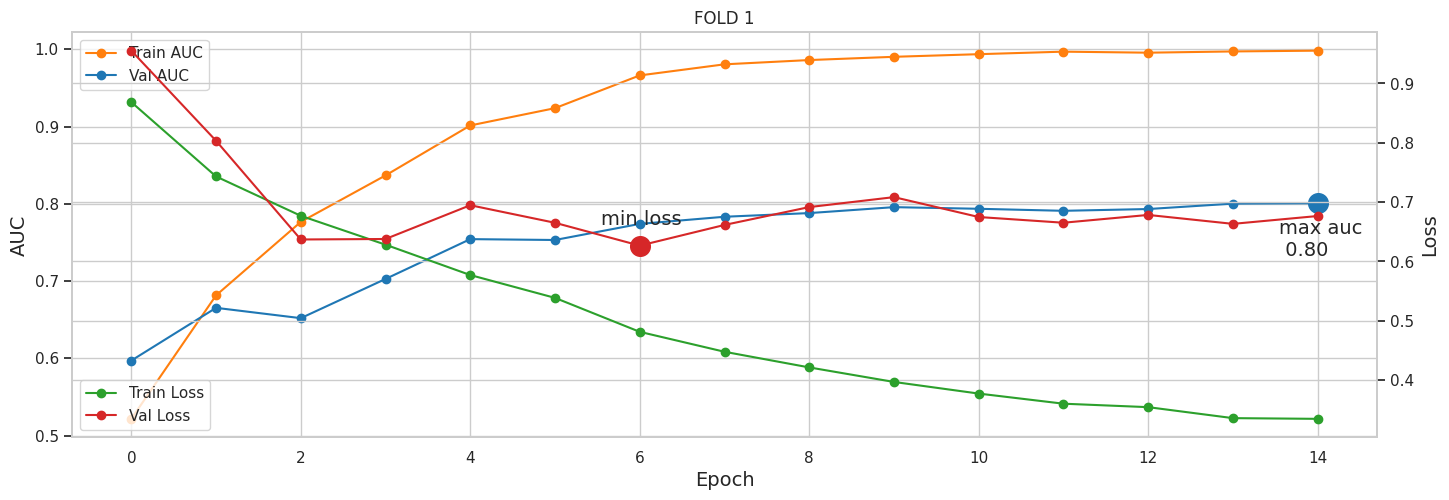


___________________________FOLD 2__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/15
107/107 [==============================] - 129s 802ms/step - loss: 0.7775 - Cross Entropy: 0.7490 - f1_score: 0.3151 - TP: 270.0000 - FP: 710.0000 - TN: 1020.0000 - FN: 128.0000 - accuracy: 0.6062 - val_acc: 0.6062 - precision: 0.2755 - recall: 0.6784 - auc: 0.6819 - prc: 0.3418 - val_loss: 0.8009 - val_Cross Entropy: 0.8000 - val_f1_score: 0.3055 - val_TP: 48.0000 - val_FP: 181.0000 - val_TN: 160.0000 - val_FN: 27.0000 - val_accuracy: 0.5000 - val_val_acc: 0.5000 - val_precision: 0.2096 - val_recall: 0.6400 - val_auc: 0.6065 - val_prc: 0.2844 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/15
107/107 [==============================] - 101s 952ms/step - loss: 0.6886 - Cross Entropy: 0.6785 - f1_score: 0.3145 - TP: 253.0000 - FP: 550.0000 - TN: 836.0000 - FN: 65.0000 - accuracy: 0.63

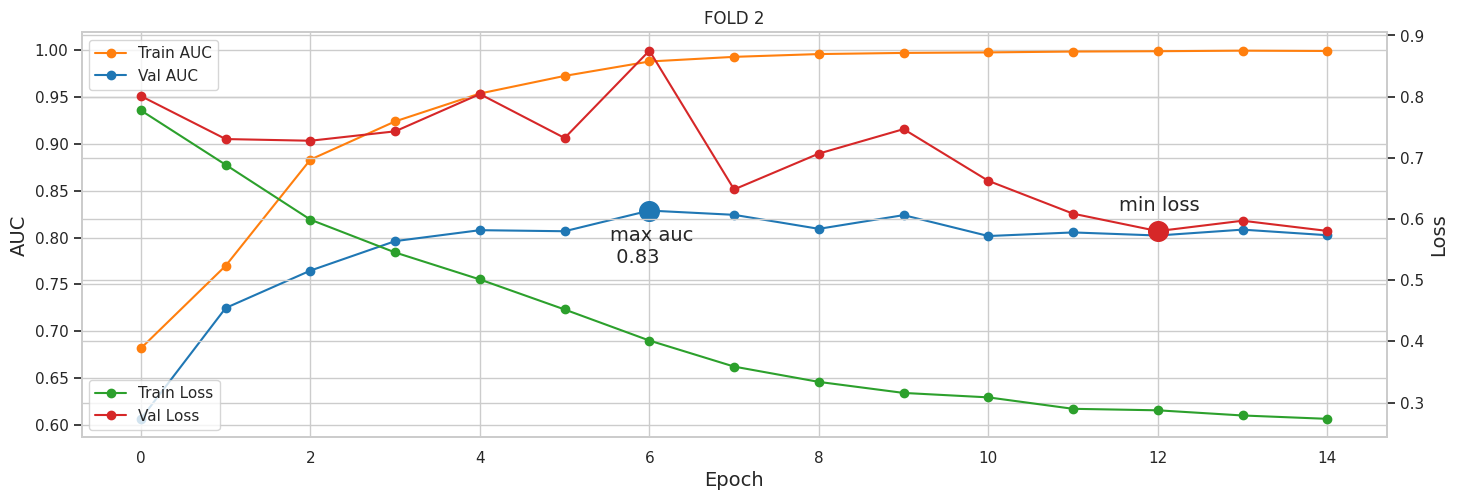


___________________________FOLD 3__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/15
107/107 [==============================] - 139s 876ms/step - loss: 0.6989 - Cross Entropy: 0.6592 - f1_score: 0.3145 - TP: 308.0000 - FP: 635.0000 - TN: 1096.0000 - FN: 89.0000 - accuracy: 0.6598 - val_acc: 0.6598 - precision: 0.3266 - recall: 0.7758 - auc: 0.7891 - prc: 0.5358 - val_loss: 0.5263 - val_Cross Entropy: 0.5041 - val_f1_score: 0.3158 - val_TP: 74.0000 - val_FP: 100.0000 - val_TN: 238.0000 - val_FN: 4.0000 - val_accuracy: 0.7500 - val_val_acc: 0.7500 - val_precision: 0.4253 - val_recall: 0.9487 - val_auc: 0.9429 - val_prc: 0.8569 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/15
107/107 [==============================] - 107s 1s/step - loss: 0.5461 - Cross Entropy: 0.5186 - f1_score: 0.3145 - TP: 286.0000 - FP: 377.0000 - TN: 1009.0000 - FN: 32.0000 - accuracy: 0.7600 -

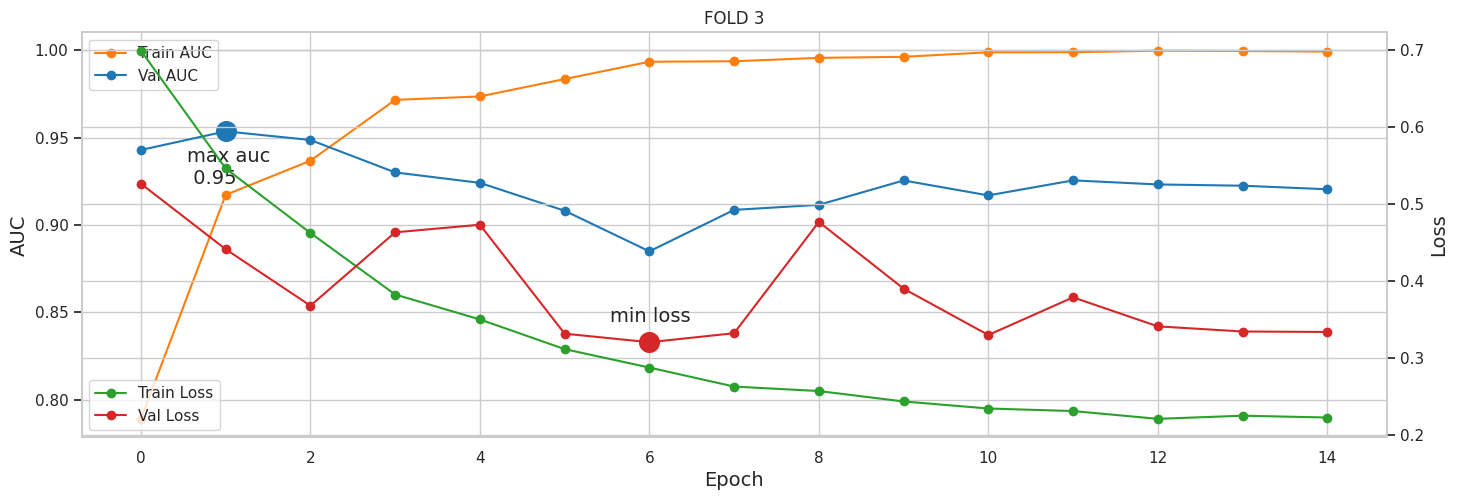


___________________________FOLD 4__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/15
107/107 [==============================] - 149s 945ms/step - loss: 0.7465 - Cross Entropy: 0.6461 - f1_score: 0.3165 - TP: 300.0000 - FP: 619.0000 - TN: 1109.0000 - FN: 100.0000 - accuracy: 0.6621 - val_acc: 0.6621 - precision: 0.3264 - recall: 0.7500 - auc: 0.7701 - prc: 0.5579 - val_loss: 0.5255 - val_Cross Entropy: 0.5085 - val_f1_score: 0.3192 - val_TP: 74.0000 - val_FP: 96.0000 - val_TN: 241.0000 - val_FN: 5.0000 - val_accuracy: 0.7572 - val_val_acc: 0.7572 - val_precision: 0.4353 - val_recall: 0.9367 - val_auc: 0.9462 - val_prc: 0.8758 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/15
107/107 [==============================] - 116s 1s/step - loss: 0.5287 - Cross Entropy: 0.5038 - f1_score: 0.3129 - TP: 289.0000 - FP: 417.0000 - TN: 971.0000 - FN: 27.0000 - accuracy: 0.7394 - 

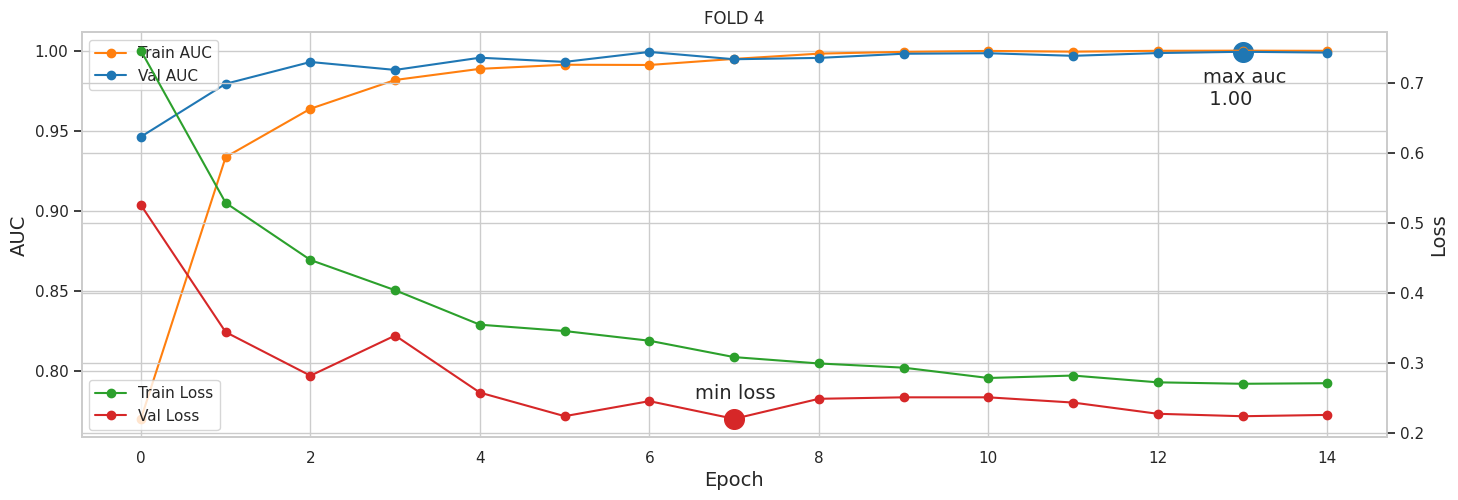


___________________________FOLD 5__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/15
107/107 [==============================] - 150s 945ms/step - loss: 0.6974 - Cross Entropy: 0.5780 - f1_score: 0.3178 - TP: 314.0000 - FP: 539.0000 - TN: 1187.0000 - FN: 88.0000 - accuracy: 0.7054 - val_acc: 0.7054 - precision: 0.3681 - recall: 0.7811 - auc: 0.8207 - prc: 0.7280 - val_loss: 0.4774 - val_Cross Entropy: 0.4453 - val_f1_score: 0.3192 - val_TP: 75.0000 - val_FP: 84.0000 - val_TN: 253.0000 - val_FN: 4.0000 - val_accuracy: 0.7885 - val_val_acc: 0.7885 - val_precision: 0.4717 - val_recall: 0.9494 - val_auc: 0.9602 - val_prc: 0.9544 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/15
107/107 [==============================] - 121s 1s/step - loss: 0.4265 - Cross Entropy: 0.3789 - f1_score: 0.3129 - TP: 298.0000 - FP: 268.0000 - TN: 1120.0000 - FN: 18.0000 - accuracy: 0.8322 - 

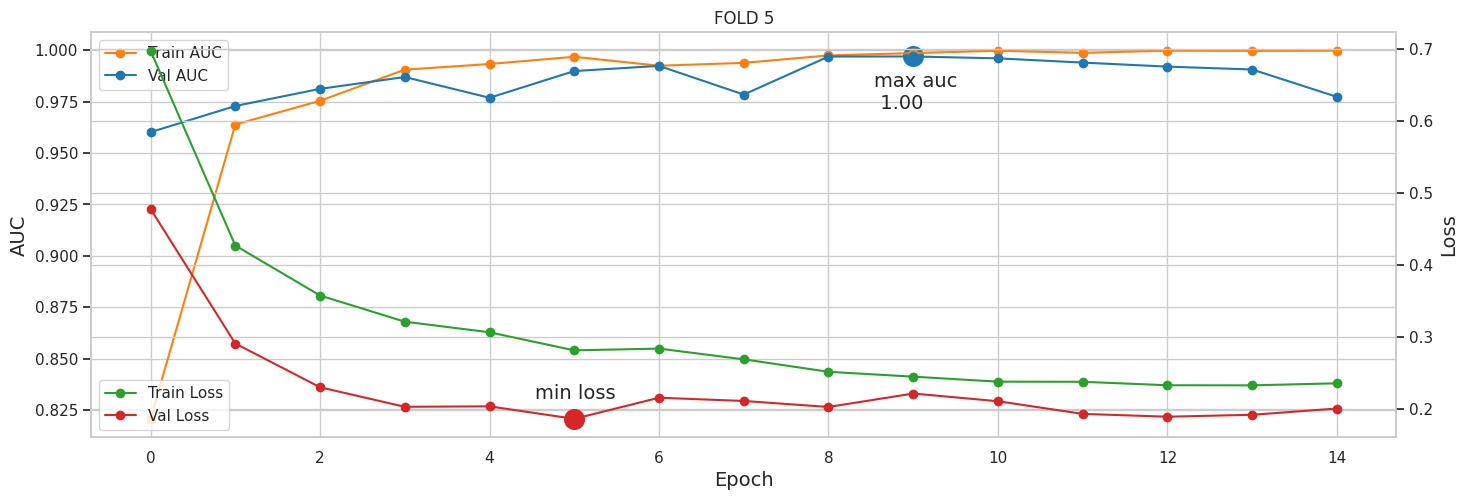

In [15]:
# 32-16-8-4
DISPLAY_PLOT = True

# Define paths
tfrec_train_files = tf.io.gfile.glob('../../../dataset/task1/tf_records/train00.tfrec')
tfrec_test_files = tf.io.gfile.glob('../../../dataset/task1/tf_records/test00.tfrec')

#Load datasets
train_data, train_labels = get_dataset(tfrec_train_files, augment = True, shuffle = True, repeat = False, dim = 224)
test_data, test_labels = get_dataset(tfrec_test_files, augment = True, shuffle = False, repeat = False, dim = 224)

# Predictions array for test set
test_preds = np.zeros((count_data_items(tfrec_test_files), 1))

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits = CONFIG.FOLDS, shuffle = True, random_state = CONFIG.SEED)
oof_pred, oof_tar, oof_val, oof_folds = [], [], [],[]

for fold, (train_idx, val_idx) in enumerate(skf.split(train_data, train_labels)):

    print(f'\n___________________________FOLD {fold + 1}__________________________\n')

    # Create train and validation datasets
    train_subset_data, train_subset_labels = train_data[train_idx], train_labels[train_idx]
    val_subset_data, val_subset_labels = train_data[val_idx], train_labels[val_idx]

    train_dataset = tf.data.Dataset.from_tensor_slices((train_subset_data, train_subset_labels))
    val_dataset = tf.data.Dataset.from_tensor_slices((val_subset_data, val_subset_labels))

    # Batch and shuffle datasets
    #.shuffle(len(train_subset_labels))
    train_dataset = train_dataset.batch(CONFIG.BATCH_SIZE[fold]).repeat()
    val_dataset = val_dataset.batch(CONFIG.BATCH_SIZE[fold])

    steps_per_epoch = len(train_subset_labels) // CONFIG.BATCH_SIZE[fold]
    validation_steps = len(val_subset_labels) // CONFIG.BATCH_SIZE[fold]

    # Class Weight

    # Build and compile model
    tf.keras.backend.clear_session()
    model = build_model(dim = 256)

    # Save best model checkpoint callback
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath = 'ViTb_16-fold-%i.h5'%fold,
                                                             monitor = 'val_loss', verbose = 0,
                                                             save_best_only = True, save_weights_only = True, mode = 'min',
                                                             save_freq = 'epoch')

    # Train Model
    print('Training ...')

    history = model.fit(train_dataset, epochs = CONFIG.EPOCHS[fold],
                        steps_per_epoch = steps_per_epoch, validation_data = val_dataset,
                        validation_steps = validation_steps, callbacks = [ checkpoint_callback,get_lr_callback(CONFIG.BATCH_SIZE[fold])],
                        verbose = CONFIG.VERBOSE)

    # Load best model weights
    print('Loading best model...')
    model.load_weights('ViTb_16-fold-%i.h5'%fold)

    # Predic OOF
    print('Predicting OOF with TTA...')
    val_preds = model.predict(val_dataset, verbose = 0)
    oof_pred.append(np.mean(val_preds, axis = 1))
    oof_tar.append(np.array([label.numpy() for _, label in val_dataset.unbatch()]))
    oof_folds.append(np.ones_like(oof_tar[-1], dtype = 'int8') * fold)

    # Predict on test set
    print('Predicting Test with TTA...')
    if fold == 0:
      test_preds = model.predict(test_data, verbose = 0)
    else:
      test_preds += model.predict(test_data, verbose = 0)

    test_preds += model.predict(test_data, verbose = 0 ) / CONFIG.FOLDS

    # cALCULATE AUC
    fold_auc = roc_auc_score(oof_tar[-1], oof_pred[-1])
    oof_val.append(np.max(history.history['val_auc']))
    print(f'#### FOLD {fold + 1} OOF AUC without TTA = {oof_val[-1]:.3f}, with TTA = {fold_auc:.3f}')

    # Plot training history
    if DISPLAY_PLOT:
        plt.figure(figsize = (15, 5))
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['auc'], '-o', label = 'Train AUC', color = '#ff7f0e')
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['val_auc'], '-o', label = 'Val AUC', color = '#1f77b4')
        x = np.argmax(history.history['val_auc'])
        y = np.max(history.history['val_auc'])
        xdist = plt.xlim()[1] - plt.xlim()[0]
        ydist = plt.ylim()[1] - plt.ylim()[0]
        plt.scatter(x, y, s = 200, color = '#1f77b4')
        plt.text(x - 0.03 * xdist, y - 0.13 * ydist, f'max auc \n {y:.2f}', size = 14)
        plt.ylabel('AUC', size = 14)
        plt.xlabel('Epoch', size = 14)
        plt.legend(loc = 2)

        plt2 = plt.gca().twinx()
        plt2.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['loss'], '-o', label = 'Train Loss', color = '#2ca02c')
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['val_loss'], '-o', label = 'Val Loss', color = '#d62728')
        x = np.argmin(history.history['val_loss'])
        y = np.min(history.history['val_loss'])
        ydist = plt.ylim()[1] - plt.ylim()[0]
        plt.scatter(x, y, s = 200, color = '#d62728')
        plt.text(x - 0.03 * xdist, y + 0.05 * ydist, 'min loss', size = 14)
        plt.ylabel('Loss', size = 14)
        plt.title(f'FOLD {fold + 1}')
        plt.legend(loc = 3)
        plt.show()

In [15]:
def test_evaluate(model, X_test, y_test):
    predictions = model.predict(X_test)
    # Convert predictions to binary (0, 1)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    # Classification Report
    report = classification_report(y_test, predicted_labels, target_names = ['Class 0', 'Class 1'], output_dict = True)

    # ROC AUC Score
    roc = roc_auc_score(y_test, predictions)
    print(f'ROC AUC Score: {roc}')

    # Confusion Matrix
    cm = confusion_matrix(y_test, predicted_labels)

    # Plot CM
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Class 0', 'Class 1'])
    disp.plot()
    plt.show()

    # Metrics
    class_nevus_keratosis = report.get('Class 0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    class_melanoma = report.get('Class 1', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})

    # Extract Metrics
    metrics_data = {
        'Metric': ['Precision', 'Recall', 'F1-Score', 'Support'],
        'Class 0': [class_nevus_keratosis['precision'], class_nevus_keratosis['recall'], class_nevus_keratosis['f1-score'], class_nevus_keratosis['support']],
        'Class 1': [class_melanoma['precision'], class_melanoma['recall'], class_melanoma['f1-score'], class_melanoma['support']],
        'Accuracy': [report['accuracy'], '', '', ''],
        'Macro-Avg': [report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score'], ''],
        'Weighted-Avg': [report['weighted avg']['precision'], report['weighted avg']['recall'], report['weighted avg']['f1-score'], ''],
        'ROC-AUC-Score': [roc, '', '', '']
    }

    # Create DataFrame
    df_metrics = pd.DataFrame(metrics_data)

    # DataFrame for CM
    #df_conf_matrix = pd.DataFrame(cm, index = ['Actual 0', 'Actual 1'], columns = ['Predicted 0', 'Predicted 1'])

    #Display tables
    print("Classification Metrics:")
    print(df_metrics.to_string(index = False))
    #print("\n Confusion Matrix:")
    #print(df_conf_matrix.to_string(index = True))



______________________FOLD 1______________________

19/19 [==============================] - 11s 446ms/step
ROC AUC Score: 0.8103201146679407


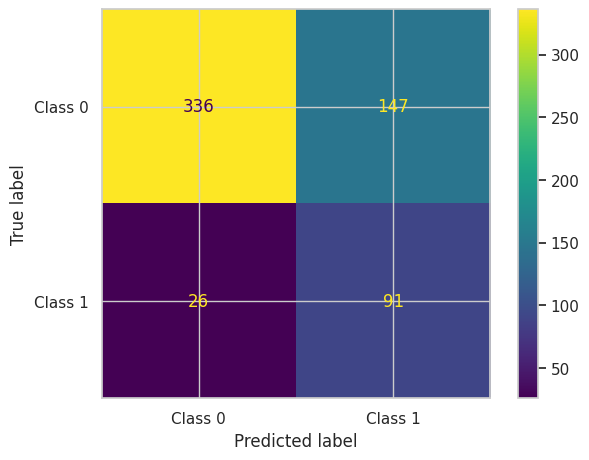

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.928177   0.382353  0.711667  0.655265     0.821741       0.81032
   Recall   0.695652   0.777778            0.736715     0.711667              
 F1-Score   0.795266   0.512676            0.653971     0.740161              
  Support 483.000000 117.000000                                               

______________________FOLD 2______________________

19/19 [==============================] - 9s 452ms/step
ROC AUC Score: 0.791934313673444


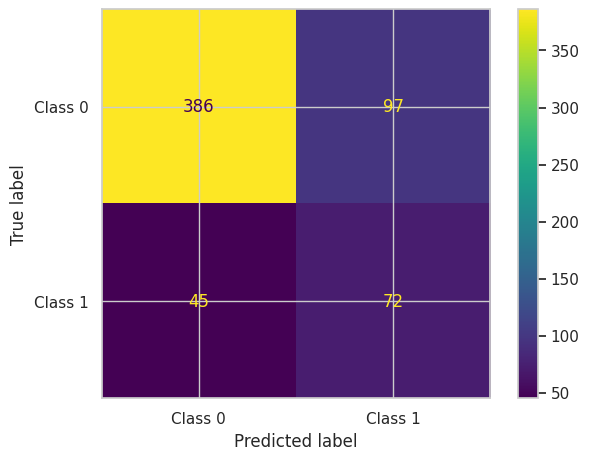

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.895592   0.426036  0.763333  0.660814     0.804028      0.791934
   Recall   0.799172   0.615385            0.707278     0.763333              
 F1-Score   0.844639   0.503497            0.674068     0.778116              
  Support 483.000000 117.000000                                               

______________________FOLD 3______________________

19/19 [==============================] - 9s 452ms/step
ROC AUC Score: 0.7513581426624905


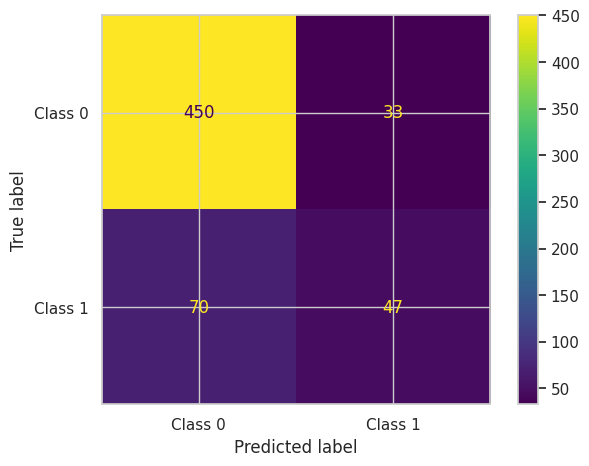

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.865385   0.587500  0.828333  0.726442     0.811197      0.751358
   Recall   0.931677   0.401709            0.666693     0.828333              
 F1-Score   0.897308   0.477157            0.687233     0.815379              
  Support 483.000000 117.000000                                               

______________________FOLD 4______________________

19/19 [==============================] - 9s 445ms/step
ROC AUC Score: 0.7661517226734618


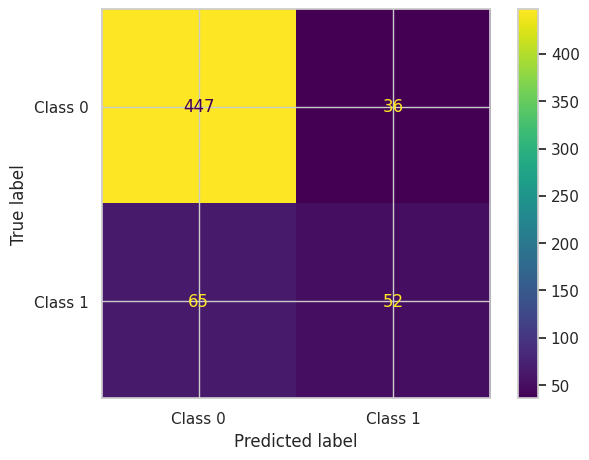

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.873047   0.590909  0.831667  0.731978      0.81803      0.766152
   Recall   0.925466   0.444444            0.684955     0.831667              
 F1-Score   0.898492   0.507317            0.702905     0.822213              
  Support 483.000000 117.000000                                               


In [17]:
# Example usage with your test data
tfrec_test = tf.io.gfile.glob(['../../../dataset/task1/tf_records/test00.tfrec'])
X_test, y_test = get_dataset(tfrec_test, augment=True, shuffle=True, repeat=False, dim = 224)

model = build_model(dim=224)
for fold in range(CONFIG.FOLDS):
    print(f"\n______________________FOLD {fold + 1}______________________\n")
    model.load_weights('ViTb_16-fold-%i.h5' % fold)
    test_evaluate(model, X_test, y_test)



______________________FOLD 1______________________

19/19 [==============================] - 513s 27s/step
ROC AUC Score: 0.7588964980269328


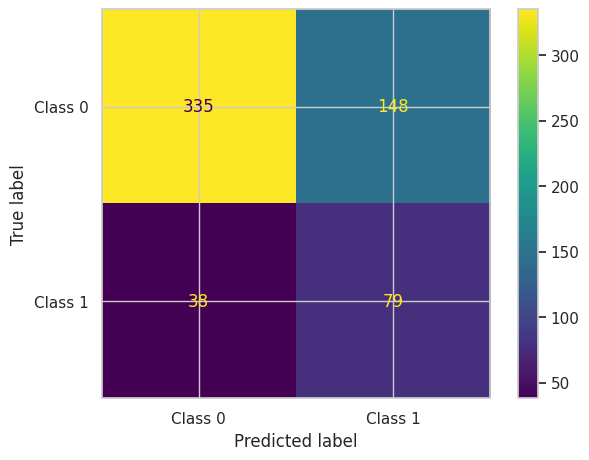

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.898123   0.348018     0.69   0.62307     0.790853      0.758896
   Recall   0.693582   0.675214           0.684398         0.69              
 F1-Score   0.782710   0.459302           0.621006     0.719646              
  Support 483.000000 117.000000                                              

______________________FOLD 2______________________

19/19 [==============================] - 507s 27s/step
ROC AUC Score: 0.780697563306259


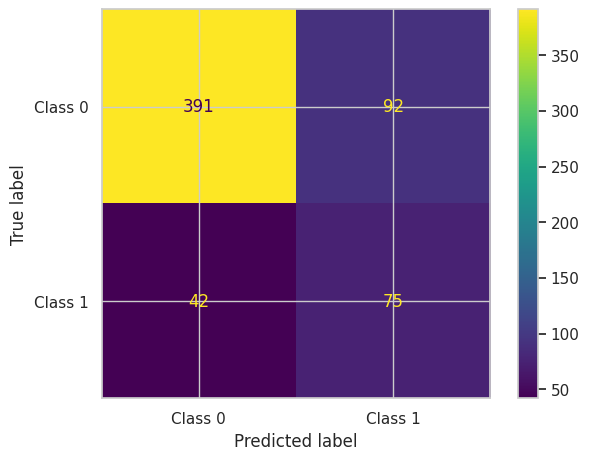

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.903002   0.449102  0.776667  0.676052     0.814492      0.780698
   Recall   0.809524   0.641026            0.725275     0.776667              
 F1-Score   0.853712   0.528169             0.69094     0.790231              
  Support 483.000000 117.000000                                               

______________________FOLD 3______________________

19/19 [==============================] - 507s 27s/step
ROC AUC Score: 0.7286015112102069


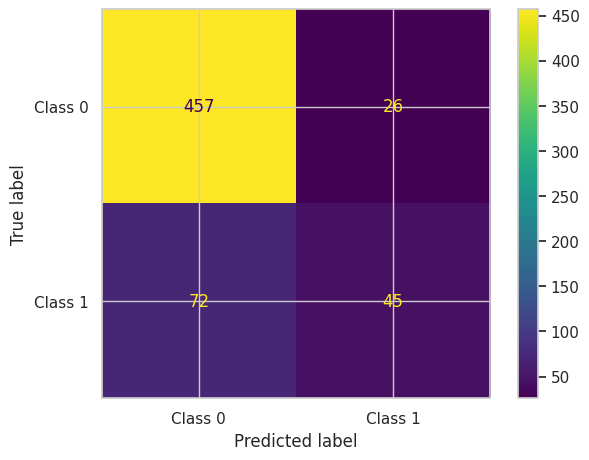

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.863894   0.633803  0.836667  0.748848     0.819026      0.728602
   Recall   0.946170   0.384615            0.665393     0.836667              
 F1-Score   0.903162   0.478723            0.690943     0.820397              
  Support 483.000000 117.000000                                               

______________________FOLD 4______________________

19/19 [==============================] - 507s 27s/step
ROC AUC Score: 0.7572154093893224


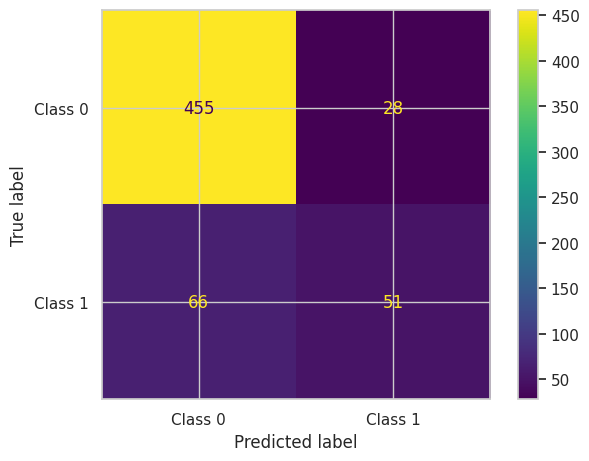

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.873321   0.645570  0.843333  0.759445     0.828909      0.757215
   Recall   0.942029   0.435897            0.688963     0.843333              
 F1-Score   0.906375   0.520408            0.713391     0.831111              
  Support 483.000000 117.000000                                               

______________________FOLD 5______________________

19/19 [==============================] - 497s 26s/step
ROC AUC Score: 0.7273805099892057


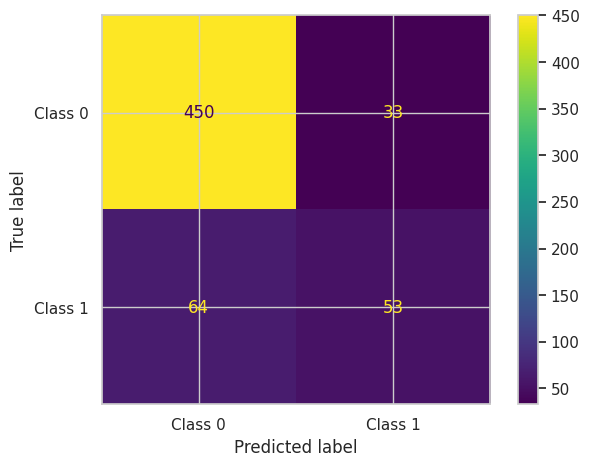

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.875486   0.616279  0.838333  0.745883     0.824941      0.727381
   Recall   0.931677   0.452991            0.692334     0.838333              
 F1-Score   0.902708   0.522167            0.712438     0.828503              
  Support 483.000000 117.000000                                               


In [16]:
# Example usage with your test data
tfrec_test = tf.io.gfile.glob(['../../../dataset/task1/tf_records/test00.tfrec'])
X_test, y_test = get_dataset(tfrec_test, augment=True, shuffle=True, repeat=False, dim = 224)

model = build_model(dim=224)
for fold in range(CONFIG.FOLDS):
    print(f"\n______________________FOLD {fold + 1}______________________\n")
    model.load_weights('ViTb_16-fold-%i.h5' % fold)
    test_evaluate(model, X_test, y_test)
